### Importing

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.stats import uniform , randint
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder , label_binarize
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , roc_curve , auc

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Diabetes_risk.csv")
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


### EDA

In [3]:
df.shape

(50000, 42)

In [4]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed', 'Diabetes_Risk', 'BMI_CATEGORY'],
      dtype='object')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
pd.DataFrame(data = {"Missing Count" : missing})

,Missing Count
Weight_kg,2962
Height_cm,2945
Sleep_Hours,2017
Exercise_Hours_Per_Week,1992
HbA1c,1974
Daily_Walking_Minutes,1964
LDL,1000
Triglycerides,1000
Total_Cholesterol,1000
HDL,1000


In [7]:
for col in df.select_dtypes(include = [np.number]).columns.tolist():
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include = ["object"]).columns.tolist():
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,50000.0,25000.500000,14433.901067,1.0,12500.750,25000.5,37500.25,50000.0
Age,50000.0,53.872380,21.024870,18.0,36.000,54.0,72.00,90.0
Height_cm,50000.0,170.017706,14.025535,145.0,158.300,170.0,181.80,195.0
Weight_kg,50000.0,87.447702,23.763593,45.0,67.700,87.3,107.20,130.0
BMI,50000.0,30.924056,10.290091,11.9,22.700,30.0,37.80,61.7
Waist_Circumference_cm,50000.0,99.960790,23.086579,60.0,80.000,99.8,119.90,140.0
Blood_Glucose,50000.0,159.905144,51.539079,70.0,115.500,159.9,204.20,250.0
HbA1c,50000.0,8.488532,2.267625,4.5,6.600,8.5,10.40,12.5
Fasting_Blood_Sugar,50000.0,142.607294,44.681799,65.0,103.900,142.6,181.50,220.0
Insulin_Level,50000.0,23.476724,12.403841,2.0,12.800,23.4,34.30,45.0


In [9]:
df.describe(include = ["object"]).T.sort_values(by = ["unique"] , ascending = False)

,count,unique,top,freq
Country,50000,25,Malaysia,2083
AI_Health_Recommendation,50000,15,Strict Blood Sugar Monitoring,7481
Work_Type,50000,5,Business,10167
BMI_CATEGORY,50000,4,Obese,24999
Alcohol_Consumption,50000,3,Never,16712
Diabetes_Risk,50000,3,High,36593
Medication_Adherence,50000,3,Good,17361
Gender,50000,3,Male,16718
Smoking_Status,50000,3,Former,16729
Stress_Level,50000,3,Low,16725


In [10]:
df = df.drop(columns = ["Patient_ID"])

In [11]:
df["Diabetes_Risk"].value_counts()

Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: int64

### Feature & Target Split

In [12]:
X = df.drop(columns = ["Diabetes_Risk"])
y = df["Diabetes_Risk"]

### Preprocessing Data

In [13]:
categorical_cols = X.select_dtypes(include = ['object']).columns

for col in categorical_cols:
    if X[col].nunique() == 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        
    elif X[col].nunique() > 2:
        X = pd.get_dummies(X , columns = [col] , drop_first = True , dtype = int)

### Train & Test Split

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101 , stratify = y)

### Model Training

In [35]:
model = LGBMClassifier(n_estimators = 110 , learning_rate = 0.15 , subsample = 0.4 , subsample_freq = 1 , random_state = 101)
model.fit(X_train , y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026640 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3875
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 89
[LightGBM] [Info] Start training from score -0.312180
[LightGBM] [Info] Start training from score -4.667046
[LightGBM] [Info] Start training from score -1.351893
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.15
,n_estimators,110
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Prediction

In [37]:
y_pred = model.predict(X_test)

### Evaluation

In [38]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7319
         Low       1.00      1.00      1.00        94
    Moderate       1.00      1.00      1.00      2587

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



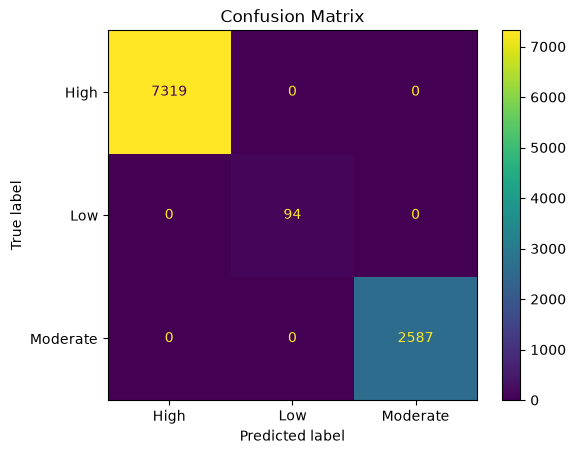

In [39]:
ConfusionMatrixDisplay.from_estimator(estimator = model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

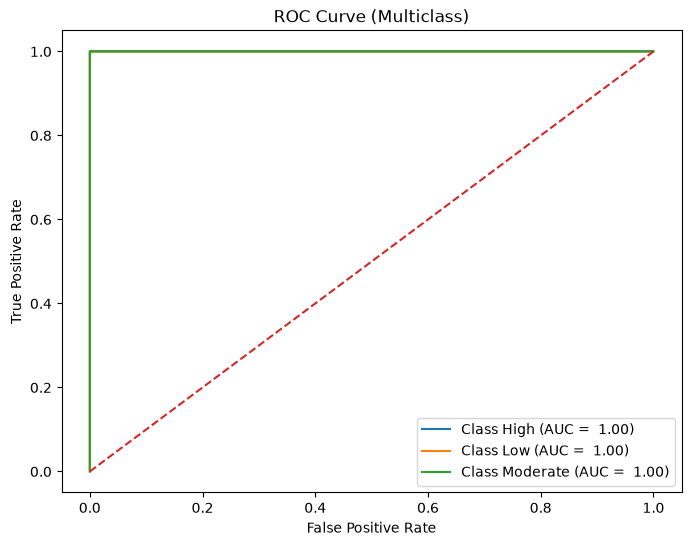

In [40]:
y_score = model.predict_proba(X_test)

classes = model.classes_

y_test_bin = label_binarize(y_test , classes = classes)

plt.figure(figsize = (8 , 6))

for i , cls in enumerate(classes):
    fpr , tpr , _ = roc_curve(y_test_bin[: , i] , y_score[: , i])
    roc_auc = auc(fpr , tpr)
    plt.plot(fpr , tpr , label = f"Class {cls} (AUC = {roc_auc : .2f})")

plt.plot([0 , 1] , [0 , 1] , "--")
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()